In [8]:
from results_utils import compute_results, plot_mean_std_for_model, load_results_paths, compute_metric, boxplot_for_model, plot_manual_boxplot_for_model
import os
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# metrics = ["norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
# # metrics = ["norm_error_rate", "norm_cross_entropy"]
# bootstrap = 0
# random_state = 42
# df_results = compute_results(metrics, bootstrap, random_state)

In [10]:
# plot_mean_std_for_model(df_results, "lm_tinyllama", metrics[:-1], width = 0.5, err=False, stat="median")

In [11]:
metrics = ["norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
# metrics = ["norm_error_rate", "norm_cross_entropy"]
bootstrap = 0
random_state = 42

if os.path.exists(f"results_{bootstrap}_{random_state}.csv"):
    df = pd.read_csv(f"results_{bootstrap}_{random_state}.csv", index_col=False)
else:
    df = compute_results(metrics, bootstrap, random_state)
    df.to_csv(f"results_{bootstrap}_{random_state}.csv", index=False)
# df = compute_results(metrics, bootstrap, random_state)
df.loc[:,[c for c in df.columns if ":" not in c ]]

,dataset,size,num_samples,prompt,n_shots,model,base_method,cal_method,split,norm_error_rate,norm_cross_entropy,ece,cal_loss_bias,norm_min_calibration_bias
0,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,lora,affine_scalar_train_on_val,test,0.160 ± 0.025,0.300 ± 0.028,0.020 ± 0.004,4.539 ± 4.300,0.288 ± 0.020
1,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,lora,no_calibration,test,0.172 ± 0.034,0.330 ± 0.045,0.032 ± 0.013,12.502 ± 8.130,0.288 ± 0.020
2,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.326 ± 0.007,0.532 ± 0.012,0.032 ± 0.009,5.601 ± 2.161,0.506 ± 0.001
3,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.318 ± 0.000,0.683 ± 0.000,0.176 ± 0.001,26.436 ± 0.084,0.506 ± 0.001
4,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.309 ± 0.007,0.682 ± 0.000,0.186 ± 0.004,26.360 ± 0.089,0.506 ± 0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,banking77,4,308,basic_banking77_0-shot_litgpt,0,lm_tinyllama,lora,no_calibration,test,0.496 ± 0.040,0.601 ± 0.060,0.169 ± 0.026,54.524 ± 3.564,0.275 ± 0.008
110,banking77,4,308,basic_banking77_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.447 ± 0.006,0.427 ± 0.011,0.045 ± 0.021,16.121 ± 2.142,0.361 ± 0.000
111,banking77,4,308,basic_banking77_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.882 ± 0.001,1.783 ± 0.000,0.487 ± 0.001,79.937 ± 0.006,0.361 ± 0.000
112,banking77,4,308,basic_banking77_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.453 ± 0.010,0.433 ± 0.017,0.034 ± 0.005,17.341 ± 3.301,0.361 ± 0.000


In [12]:
# df_lora_cal = df.loc[
#     (df["base_method"] == "lora_xval") & \
#     ((df["cal_method"] == "no_calibration") | \
#      (df["cal_method"] == "affine_scalar")  | \
#      (df["cal_method"] == "temp_scaling") | \
#      (df["cal_method"] == "bias_only")),
#     ["dataset", "size", "base_method", "cal_method", "norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
# ]
# df_results = df.loc[(df["base_method"] != "lora_xval") | (df["cal_method"] != "no_calibration"), :]

# df_results = df.loc[(df["base_method"] != "lora_xval") & (df["cal_method"] != "affine_scalar_no_es"), :]
# df_results = df_results.loc[
#     (df_results["cal_method"] != "affine_scalar_train_on_val") |
#     ((df_results["cal_method"] == "affine_scalar_train_on_val") & \
#     (df_results["size"] >= 16)),
# :]

df_results = df
# df_lora_cal

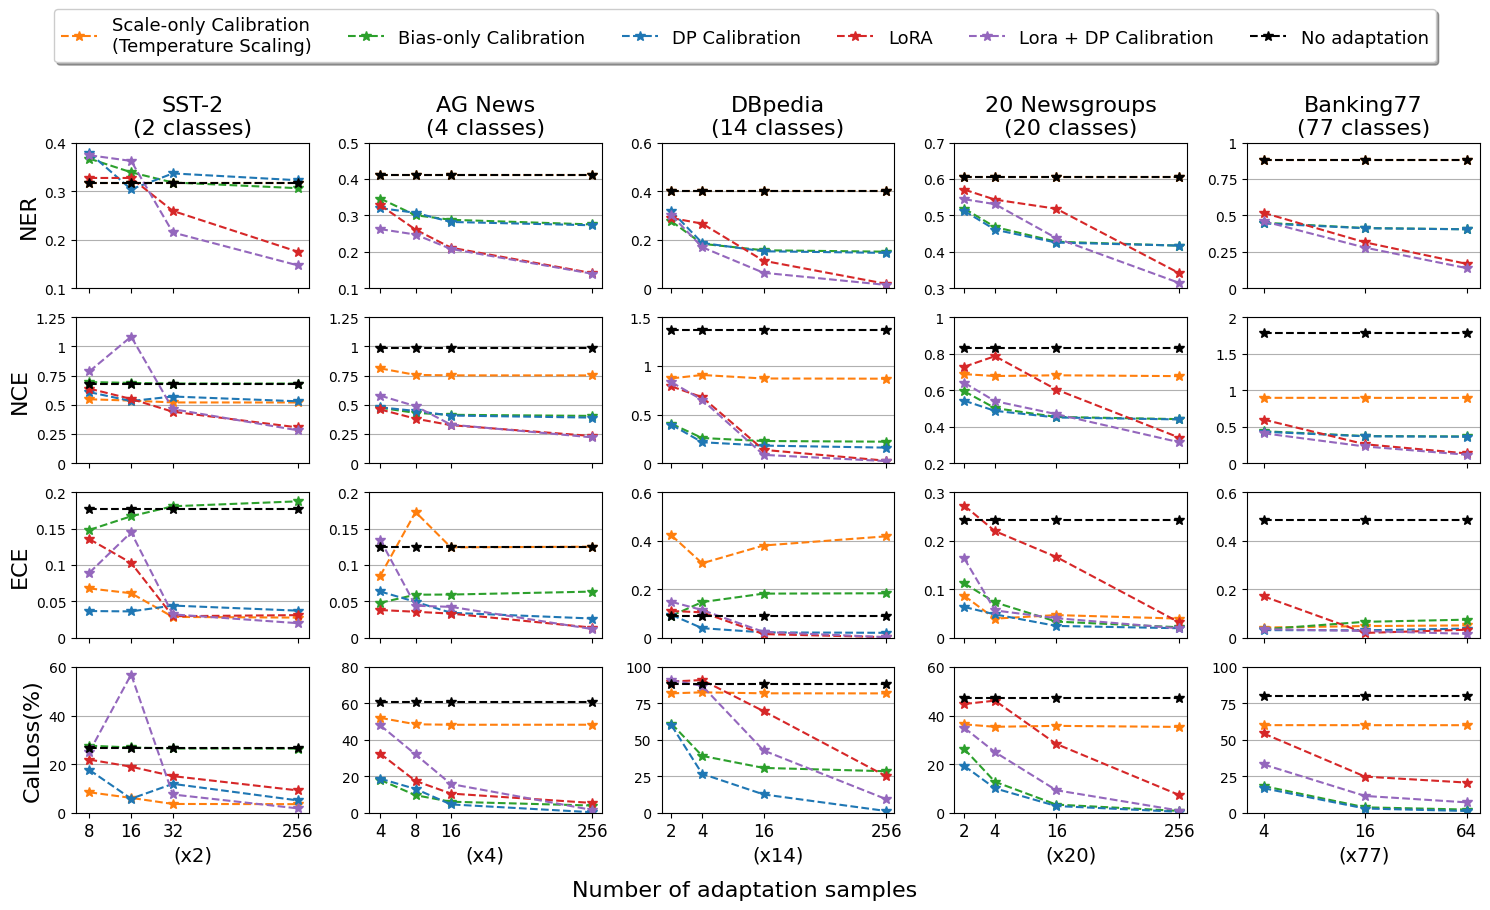

In [13]:
# plot_results_for_model(df_results, "lm_tinyllama", ["norm_error_rate", "norm_cross_entropy", "cal_loss_bias", "ece"], width = 0.5)
plot_mean_std_for_model(df_results, "lm_tinyllama", metrics[:-1], width = 0.5, err=False, stat="median")

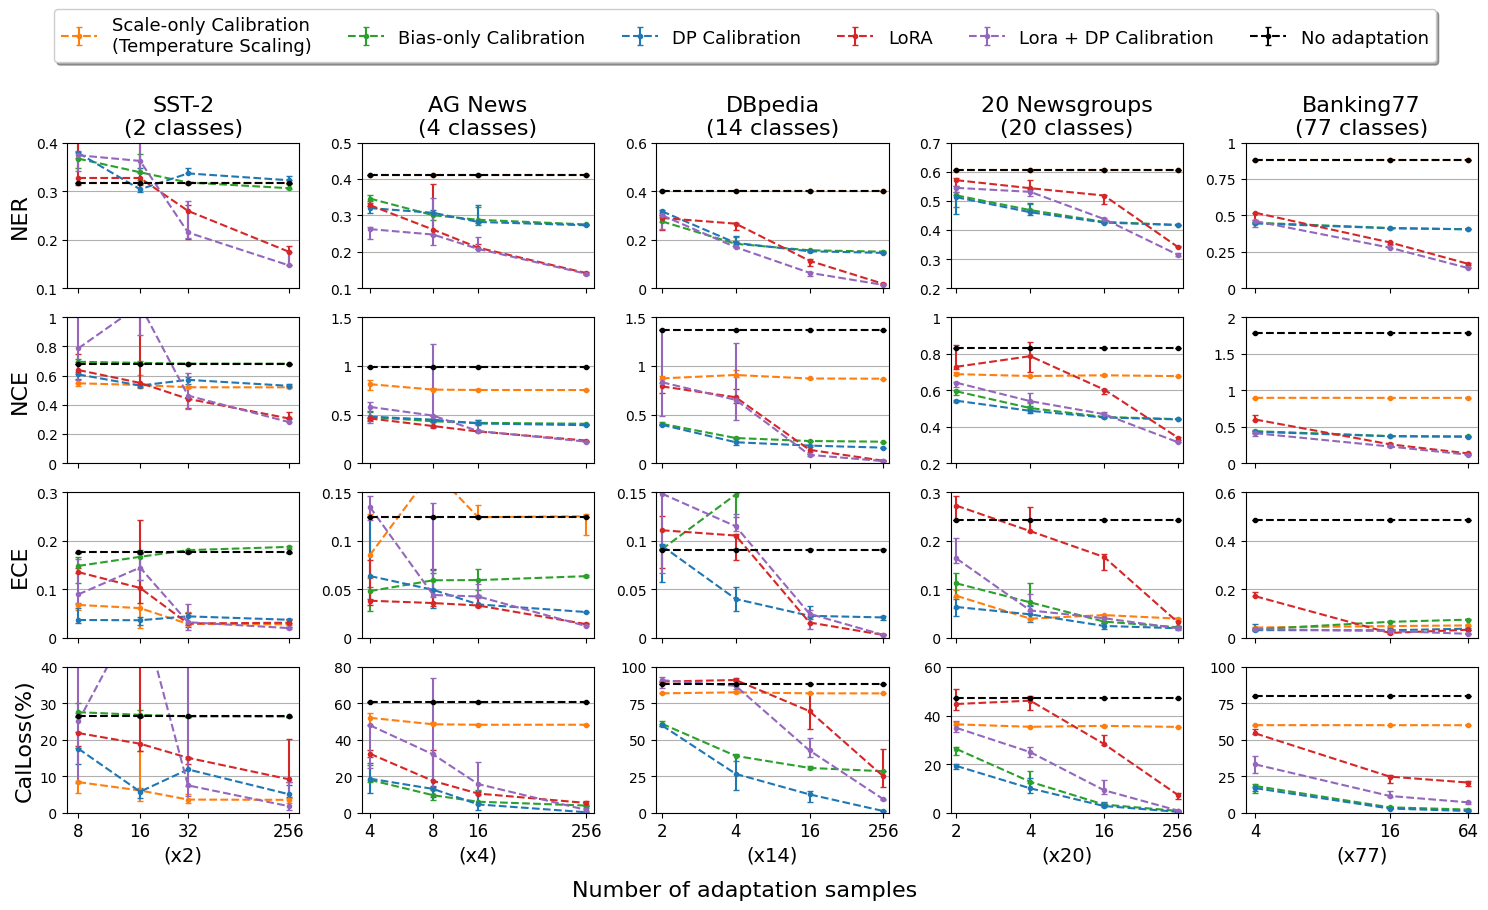

In [8]:
plot_manual_boxplot_for_model(df_results, "lm_tinyllama", metrics[:-1], width = 0.5)

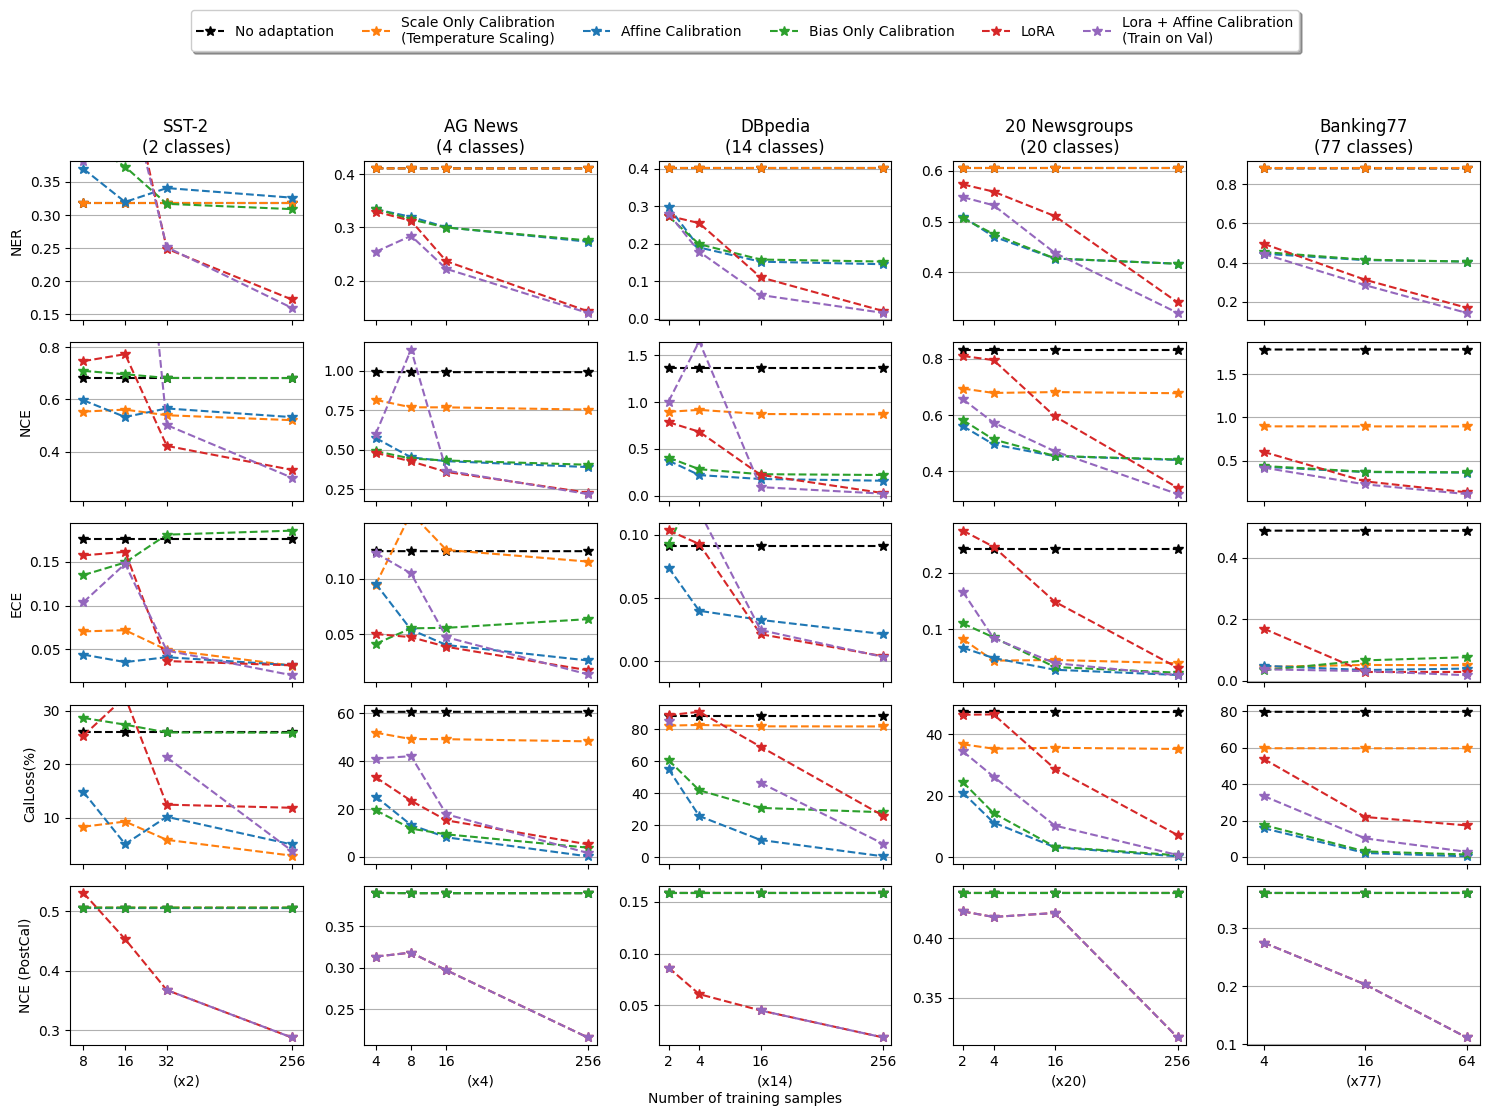

In [6]:
plot_mean_std_for_model(df_results, "lm_tinyllama", metrics, width = 0.5, err=False, stat="mean")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 5 and the array at index 2 has size 4

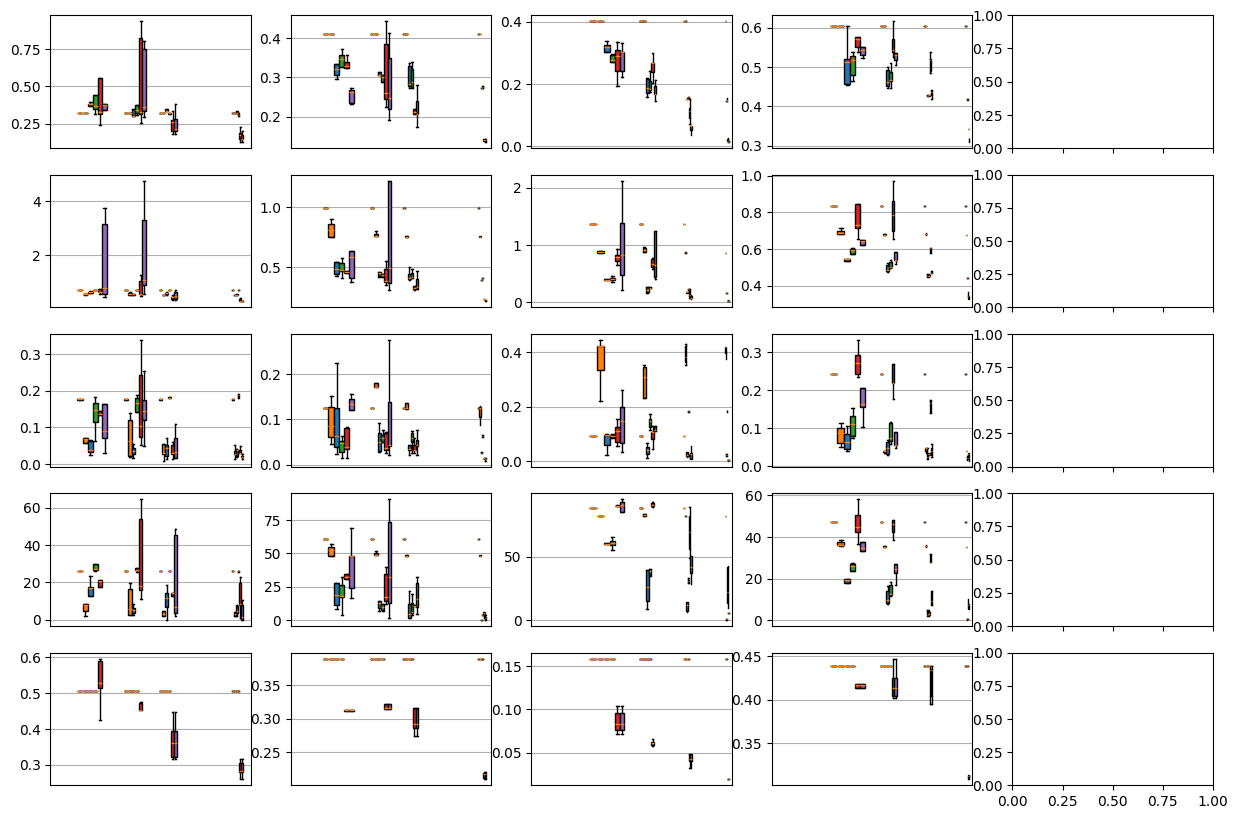

In [7]:
boxplot_for_model(df_results, "lm_tinyllama", metrics, width = 0.5)

In [ ]:
# df_results[df_results["dataset"] == "dbpedia"]
for idx, group in df[df["cal_method"] == "affine_scalar_train_on_val"].groupby(["dataset", "size"]):
    print(group.loc[:,["dataset", "size", "cal_loss_bias"]])
    print()

KeyError: "['cal_loss_bias'] not in index"